In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
import torch
import numpy as np
from scipy.special import softmax
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Model setup
MODEL_NAME = "hannybal/disaster-twitter-xlm-roberta-al"
TOKENIZER_NAME = "cardiffnlp/twitter-xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
config = AutoConfig.from_pretrained(MODEL_NAME)

In [3]:
# Data preprocessing
def preprocess(text: str) -> str:
    new_text = []
    for t in text.split(" "):
        t = "@user" if t.startswith("@") else t
        t = "http" if t.startswith("http") else t
        new_text.append(t)
    return " ".join(new_text)

In [4]:
# Text classification
def classify(text):
    preprocessed = preprocess(text)
    encoded_input = tokenizer(preprocessed, return_tensors='pt')
    with torch.no_grad():
        output = model(**encoded_input)

    scores = output.logits[0].numpy()
    probs = softmax(scores)

    results = [
        {"label": config.id2label[i], "score": float(probs[i])}
        for i in probs.argsort()[::-1]
    ]
    return results

In [5]:
#Example tweets
examples = [
    "Explosion at the airport. Multiple injuries reported.",
    "I had a great day at the park with my dog.",
    "Severe flooding in the downtown area after heavy rains.",
    "El terremoto destruyó varios edificios en el centro.",
    "Feuer bricht in einem Wohnhaus aus. Bewohner evakuiert.",
    "It's just a drill, don't panic.",
    "Felt like the whole building shook—turns out it was just my upstairs neighbor dropping weights",
    "ACTIVE SHOOTER!! The 37 lightskin male just hit his 8th shot of the night.",
    "Bus crash on Highway 5. Multiple fatalities reported. Avoid the area.",
    "That smoke? Just the BBQ competition down the block. Smells like chaos.",
    "People screaming outside—turns out it was a surprise birthday party with fireworks.",
    "Caught the sunset with my best friend. Simple moments, big joy.",
    "Help! There’s a massive fire on 4th street!",
    "RT @disaster_news: Stay safe everyone in Florida!"
]
inference_data = []

#Run inferences + save results
for text in examples:
    result = classify(text)
    top_result = result[0]  # Highest label
    print(f"\n🔎 Text: {text}")
    for r in result:
        print(f"➡️ {r['label']}: {r['score']:.4f}")
    inference_data.append({
        "text": text,
        "top_label": top_result["label"],
        "confidence": round(top_result["score"], 4),
        "alt_label": result[1]["label"],
        "alt_score": round(result[1]["score"], 4)
    })

df = pd.DataFrame(inference_data)
df.to_csv("inference_results.csv", index=False)
print("\nInference results saved to inference_results.csv")



🔎 Text: Explosion at the airport. Multiple injuries reported.
➡️ LABEL_1: 0.8506
➡️ LABEL_0: 0.1494

🔎 Text: I had a great day at the park with my dog.
➡️ LABEL_0: 0.9999
➡️ LABEL_1: 0.0001

🔎 Text: Severe flooding in the downtown area after heavy rains.
➡️ LABEL_1: 0.9999
➡️ LABEL_0: 0.0001

🔎 Text: El terremoto destruyó varios edificios en el centro.
➡️ LABEL_1: 0.9999
➡️ LABEL_0: 0.0001

🔎 Text: Feuer bricht in einem Wohnhaus aus. Bewohner evakuiert.
➡️ LABEL_1: 0.9999
➡️ LABEL_0: 0.0001

🔎 Text: It's just a drill, don't panic.
➡️ LABEL_0: 0.9999
➡️ LABEL_1: 0.0001

🔎 Text: Felt like the whole building shook—turns out it was just my upstairs neighbor dropping weights
➡️ LABEL_0: 0.9999
➡️ LABEL_1: 0.0001

🔎 Text: ACTIVE SHOOTER!! The 37 lightskin male just hit his 8th shot of the night.
➡️ LABEL_0: 0.9999
➡️ LABEL_1: 0.0001

🔎 Text: Bus crash on Highway 5. Multiple fatalities reported. Avoid the area.
➡️ LABEL_0: 0.9997
➡️ LABEL_1: 0.0003

🔎 Text: That smoke? Just the BBQ competiti

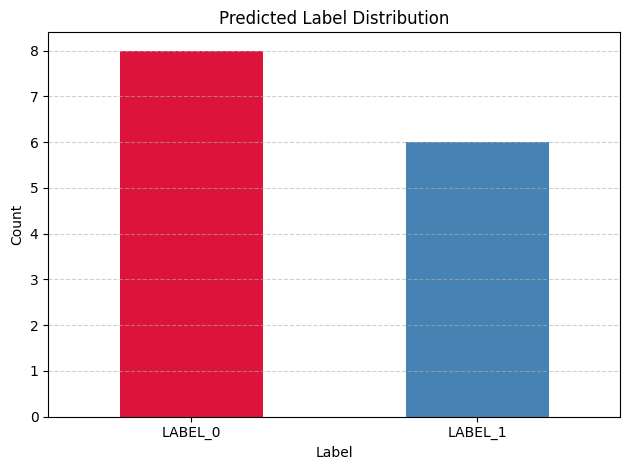

In [6]:
#Visualize distributions
label_counts = df["top_label"].value_counts()
label_counts.plot(kind="bar", color=["crimson", "steelblue"])
plt.title("Predicted Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()